<font color = green >

## Home Task

</font>

Apply various clustering algorithms 

- Agglomerative clustering using `complete` linkage 
- Agglomerative clustering using `single` linkage 
- DBSCAN
- Use albow method to determine the best k for Kmeans


<font color = green >

###  Data 

</font>



In [65]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
# %matplotlib notebook

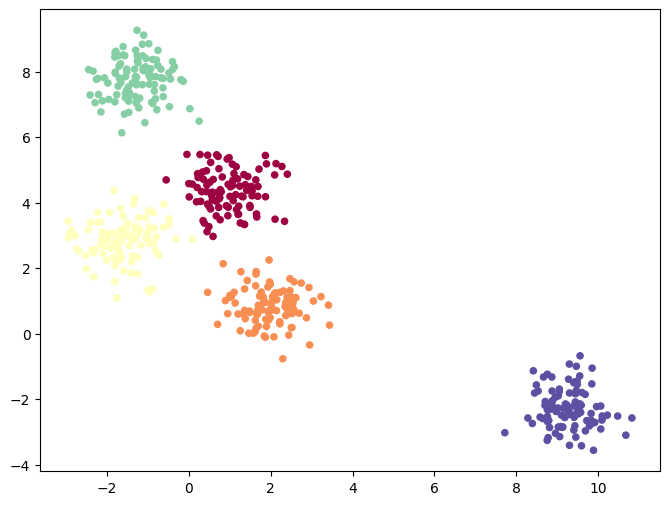

In [66]:
X, y = make_blobs(n_samples = 500, n_features = 2, centers = 5, 
                           cluster_std = 0.6, random_state = 0)
colors = np.array([plt.cm.Spectral(val)
          for val in np.linspace(0, 1, len(set(y)))])
plt.figure(figsize=(8,6))

plt.scatter(X[:,0], X[:,1], c= colors[y], s= 20)    

<font color = green >

###  Agglomerative clustering using `complete` linkage 

</font>



In [67]:
clf = AgglomerativeClustering(n_clusters=5, linkage= 'complete')
predicted = clf.fit_predict(X)

Text(0.5, 1.0, 'sklearn AgglomerativeClustering with complete linkage')

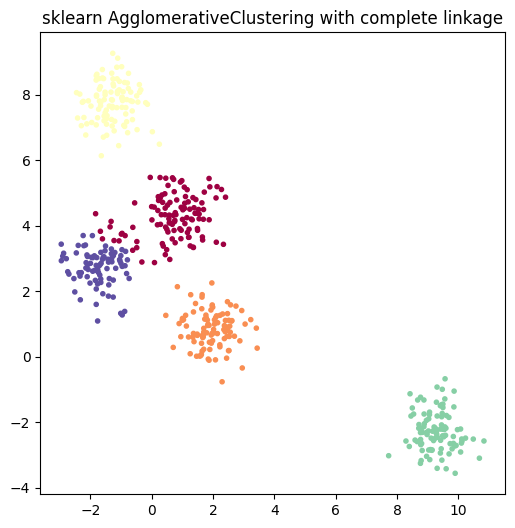

In [68]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c= colors[predicted], marker= '.') 
plt.title ('sklearn AgglomerativeClustering with complete linkage')

It is not ideal, since it misclassifies some data points as part of a nearby cluster.

<font color = green >

###  Agglomerative clustering using `single` linkage 

</font>



Text(0.5, 1.0, 'sklearn AgglomerativeClustering with single linkage')

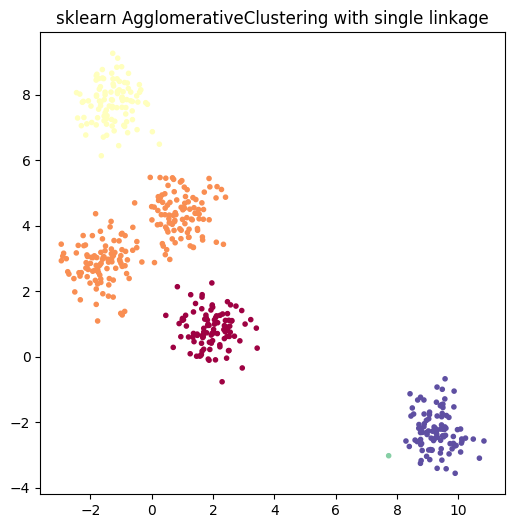

In [69]:
clf = AgglomerativeClustering(n_clusters=5, linkage= 'single')
predicted = clf.fit_predict(X)

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c= colors[predicted], marker= '.') 
plt.title ('sklearn AgglomerativeClustering with single linkage')

Single linkage handled this task worse than complete linkage, since it merged two close clusters into one.

<font color = green >

###  DBSCAN

</font>



DBSCAN found 5 clusters in the data


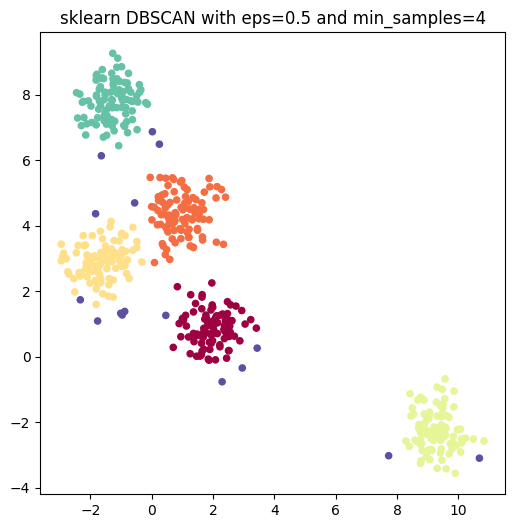

In [70]:
def apply_dbscan(points, eps, min_samples = 5):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples).fit(points) 
    clusters = dbscan.labels_

    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    print(f'DBSCAN found {n_clusters} clusters in the data')

    clusters[np.where(clusters == -1)] = len(np.unique(clusters))-1

    plt.figure(figsize=(6,6))
    plt.title (f'sklearn DBSCAN with eps={eps} and min_samples={min_samples}')
    
    if len(set(clusters)) > len(set(y)):
        colors_new = np.array([plt.cm.Spectral(val)
            for val in np.linspace(0, 1, len(set(clusters)))])
        plt.scatter(points[:,0], points[:,1], c= colors_new[clusters],s= 20)
    else:
        plt.scatter(points[:,0], points[:,1], c= colors[clusters], s= 20)

apply_dbscan(X, eps=0.5, min_samples=4)
    

DBSCAN separated these two clusters the best, but marked some data points as noise. However, it required tuning of eps and min_samples first to make it handle this task properly.

<font color = green >

###  Elbow method for Kmeans
 

</font>



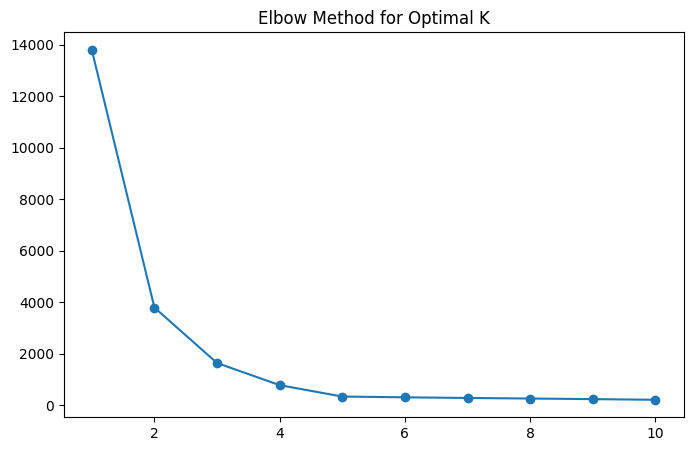

In [71]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.title('Elbow Method for Optimal K')
plt.plot(range(1, 11), inertia, marker='o')

Based on the plot, the elbow appears around K = 4, since the decrease in inertia becomes less noticeable after this point. However, the drop from K = 4 to K = 5 is still noticeable, even if smaller. This suggests that K = 5 may still provide a meaningful improvement. Since the true number of clusters in the data is 5, the elbow method slightly underestimates K in this case.

In [72]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X)

KMeans(n_clusters=5, random_state=42)

Text(0.5, 1.0, 'sklearn KMeans with n_clusters=5')

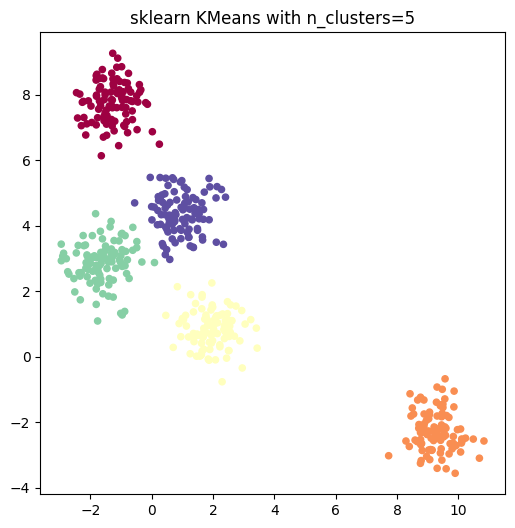

In [73]:
predicted = kmeans.labels_
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c= colors[predicted], s= 20)
plt.title('sklearn KMeans with n_clusters=5')

It looks like, if K is chosen properly, this algorithm suits this task best.